<a href="https://colab.research.google.com/github/pammikavitha/Jenkin/blob/main/uncertinity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#STEP 1 — Install Dependencies
!pip install -q pandas numpy matplotlib scikit-learn tqdm
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets timm
!pip install -q grad-cam

In [5]:
#STEP 2 — DOWNLOAD OPEN ICU DATASET Official site: eICU Demo Dataset

!wget -r -N -c -np \https://physionet.org/files/eicu-crd-demo/2.0/

--2026-05-16 12:38:00--  https://physionet.org/files/eicu-crd-demo/2.0/
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/eicu-crd-demo/2.0/index.html’

physionet.org/files     [ <=>                ]   4.21K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-05-16 12:38:00 (832 MB/s) - ‘physionet.org/files/eicu-crd-demo/2.0/index.html’ saved [4306]

Loading robots.txt; please ignore errors.
--2026-05-16 12:38:00--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 22 [text/plain]
Saving to: ‘physionet.org/robots.txt’

physionet.org/robot 100%[===================>]      22  --.-KB/s    in 0s      

2026-05-16 12:38:00 (15.9 MB/s) - ‘physionet.org/robots.txt’ saved [22/22]

--

In [6]:
#STEP 3 — LOAD STRUCTURED ICU DATA
import pandas as pd

patient = pd.read_csv(
    "/content/physionet.org/files/eicu-crd-demo/2.0/patient.csv.gz"
)

vital = pd.read_csv(
    "/content/physionet.org/files/eicu-crd-demo/2.0/vitalPeriodic.csv.gz"
)

lab = pd.read_csv(
    "/content/physionet.org/files/eicu-crd-demo/2.0/lab.csv.gz"
)

In [7]:
#STEP 4 — CREATE MORTALITY LABELS
patient['mortality'] = (
    patient['hospitaldischargestatus']
    == 'Expired'
).astype(int)

labels = patient[
    ['patientunitstayid', 'mortality']
]

In [8]:
#STEP 5 — SELECT IMPORTANT VITALS
important_cols = [
    'temperature',
    'heartrate',
    'respiration',
    'sao2',
    'systemicsystolic',
    'systemicdiastolic'
]

vital = vital[
    ['patientunitstayid'] + important_cols
]

In [9]:
#STEP 6 — HANDLE MISSING VALUES
vital = vital.fillna(
    vital.median(numeric_only=True)
)

In [10]:
#STEP 7 — BUILD EHR SEQUENCES
import numpy as np

X_ehr = vital.groupby(
    'patientunitstayid'
).mean()

X_ehr = X_ehr.values.astype(np.float32)

In [11]:
#STEP 8 — LOAD OPEN MEDICAL TEXT DATASET Official page:Medical Meadow Dataset


from datasets import load_dataset

dataset = load_dataset(
    "medalpaca/medical_meadow_medical_flashcards"
)

texts = dataset['train']['input'][:5000]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

medical_meadow_wikidoc_medical_flashcard(…):   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33955 [00:00<?, ? examples/s]

In [12]:
#STEP 9 — CLINICALBERT TEXT ENCODER
from transformers import AutoTokenizer
from transformers import AutoModel

tokenizer = AutoTokenizer.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT"
)

bert_model = AutoModel.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT"
)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
#STEP 10 — TEXT EMBEDDING EXTRACTION
import torch

def encode_text(text):

    inputs = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    with torch.no_grad():

        outputs = bert_model(**inputs)

    return outputs.last_hidden_state[:,0,:]

In [14]:
#STEP 11 — DOWNLOAD OPEN CHEST X-RAYS Official dataset:NIH ChestX-ray14



!wget https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip
!unzip master.zip

--2026-05-16 12:49:11--  https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/ieee8023/covid-chestxray-dataset/zip/refs/heads/master [following]
--2026-05-16 12:49:11--  https://codeload.github.com/ieee8023/covid-chestxray-dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.114.10
Connecting to codeload.github.com (codeload.github.com)|140.82.114.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [              <=>   ] 525.03M  25.0MB/s    in 21s     

2026-05-16 12:49:32 (25.3 MB/s) - ‘master.zip’ saved [550535079]

Archive:  master.zip
78543292f8b01d5e0ed1d0e15dce71949f0657bb
   creating: covid-chestxray-data

In [16]:

# ==========================================
# STEP 12 — IMAGE PREPROCESSING
# ==========================================

import os
from PIL import Image
from torchvision import transforms

# ------------------------------------------
# PATH TO IMAGE FOLDER
# ------------------------------------------

image_dir = "/content/covid-chestxray-dataset-master/images"

# ------------------------------------------
# GET FIRST IMAGE FILE
# ------------------------------------------

image_files = [
    f for f in os.listdir(image_dir)
    if f.endswith(('.png', '.jpg', '.jpeg'))
]

print("Total Images Found:", len(image_files))

# ------------------------------------------
# SELECT ONE IMAGE
# ------------------------------------------

image_path = os.path.join(
    image_dir,
    image_files[0]
)

print("Using Image:", image_path)

# ------------------------------------------
# IMAGE TRANSFORMS
# ------------------------------------------

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

# ------------------------------------------
# LOAD IMAGE
# ------------------------------------------

img = Image.open(image_path).convert("RGB")

# ------------------------------------------
# APPLY TRANSFORMS
# ------------------------------------------

img_tensor = transform(img)

# ------------------------------------------
# ADD BATCH DIMENSION
# ------------------------------------------

img_tensor = img_tensor.unsqueeze(0)

print("Tensor Shape:", img_tensor.shape)

Total Images Found: 924
Using Image: /content/covid-chestxray-dataset-master/images/7afaaccc.jpg
Tensor Shape: torch.Size([1, 3, 224, 224])


In [17]:
#STEP 13 — IMAGE ENCODER
import torchvision.models as models
import torch.nn as nn

image_model = models.resnet50(
    pretrained=True
)

image_model.fc = nn.Linear(2048,128)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 27.1MB/s]


In [18]:
#STEP 14 — EHR ENCODER
class EHREncoder(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,32)
        )

    def forward(self,x):

        return self.net(x)

In [19]:
#STEP 15 — MULTIMODAL FUSION MODEL
class MultiModalModel(nn.Module):

    def __init__(self, ehr_dim):

        super().__init__()

        self.ehr_encoder = EHREncoder(ehr_dim)

        self.text_proj = nn.Linear(
            768,
            32
        )

        self.image_proj = nn.Linear(
            128,
            32
        )

        self.classifier = nn.Sequential(

            nn.Linear(96,64),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,1)
        )

    def forward(
        self,
        ehr,
        text,
        image
    ):

        ehr_feat = self.ehr_encoder(ehr)

        txt_feat = self.text_proj(text)

        img_feat = self.image_proj(image)

        fused = torch.cat([
            ehr_feat,
            txt_feat,
            img_feat
        ], dim=1)

        out = self.classifier(fused)

        return out#

In [20]:
#STEP 16 — MC DROPOUT UNCERTAINTY
def mc_dropout_predict(
    model,
    ehr,
    text,
    image,
    T=20
):

    model.train()

    preds = []

    for _ in range(T):

        pred = torch.sigmoid(
            model(
                ehr,
                text,
                image
            )
        )

        preds.append(pred)

    preds = torch.stack(preds)

    mean = preds.mean()

    epistemic = preds.var()

    return mean, epistemic

In [21]:
#STEP 17 — ALEATORIC UNCERTAINTY
class AleatoricLayer(nn.Module):

    def __init__(self):

        super().__init__()

        self.mean = nn.Linear(64,1)

        self.logvar = nn.Linear(64,1)

    def forward(self,x):

        mean = self.mean(x)

        logvar = self.logvar(x)

        return mean, logvar

In [ ]:
STEP 18 — CONFLICT ENGINE

Your novel contribution:

D=Var(p^EHR,p^TEXT,p^IMG)

In [24]:
# ==========================================
# STEP 18 — CONFLICT ENGINE
# ==========================================

import torch

# ------------------------------------------
# EXAMPLE MODALITY PREDICTIONS
# ------------------------------------------

p_ehr = torch.tensor(0.82)

p_txt = torch.tensor(0.30)

p_img = torch.tensor(0.91)

# ------------------------------------------
# EXAMPLE EPISTEMIC UNCERTAINTIES
# ------------------------------------------

ue = torch.tensor([
    0.05,   # EHR uncertainty
    0.08,   # TEXT uncertainty
    0.04    # IMAGE uncertainty
])

# ------------------------------------------
# EXAMPLE ALEATORIC UNCERTAINTIES
# ------------------------------------------

ua = torch.tensor([
    0.03,
    0.06,
    0.02
])

# ------------------------------------------
# CONFLICT ENGINE FUNCTION
# ------------------------------------------

def conflict_engine(
    p_ehr,
    p_txt,
    p_img,
    ue,
    ua
):

    preds = torch.tensor([
        p_ehr,
        p_txt,
        p_img
    ])

    # Cross-modal disagreement
    D = preds.var()

    # Final deferral risk score
    R = (
        D
        + ue.sum()
        + ua.sum()
    )

    return R, D

# ------------------------------------------
# COMPUTE SCORES
# ------------------------------------------

R, D = conflict_engine(
    p_ehr,
    p_txt,
    p_img,
    ue,
    ua
)

print("Disagreement D:", D.item())
print("Deferral Risk R:", R.item())

Disagreement D: 0.10843333601951599
Deferral Risk R: 0.3884333372116089


In [26]:
# ==========================================
# STEP 19 — HUMAN DEFERRAL
# ==========================================

threshold = 0.5

if R > threshold:

    print("DEFER TO CLINICIAN")

else:

    print("AUTONOMOUS DECISION")

AUTONOMOUS DECISION


In [27]:
#STEP 20A — INSTALL XAI LIBRARIES
!pip install -q shap
!pip install -q captum
!pip install -q grad-cam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.5 MB/s eta 0:00:00


In [ ]:
#STEP 20B — STRUCTURED EHR EXPLAINABILITY (SHAP)

#SHAP explains:

#which vitals caused mortality prediction
#which labs increased risk

##Example:

#high heart rate
#low oxygen
#abnormal BP

In [29]:
# ==========================================
# CREATE MULTIMODAL MODEL INSTANCE
# ==========================================

import torch
import torch.nn as nn

# ------------------------------------------
# DEFINE INPUT DIMENSION
# ------------------------------------------

ehr_dim = X_ehr.shape[1]

print("EHR Feature Dimension:", ehr_dim)

# ------------------------------------------
# CREATE MODEL
# ------------------------------------------

model = MultiModalModel(
    ehr_dim=ehr_dim
)

print(model)

EHR Feature Dimension: 6
MultiModalModel(
  (ehr_encoder): EHREncoder(
    (net): Sequential(
      (0): Linear(in_features=6, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (text_proj): Linear(in_features=768, out_features=32, bias=True)
  (image_proj): Linear(in_features=128, out_features=32, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [30]:
#CREATE SHAP EXPLAINER
import shap
import torch

# ------------------------------------------
# SAMPLE BACKGROUND DATA
# ------------------------------------------

background = torch.tensor(
    X_ehr[:100],
    dtype=torch.float32
)

# ------------------------------------------
# SHAP EXPLAINER
# ------------------------------------------

explainer = shap.DeepExplainer(
    model.ehr_encoder,
    background
)

In [34]:
# ==========================================
# CORRECT SHAP IMPLEMENTATION
# ==========================================

import shap
import torch
import numpy as np

# ------------------------------------------
# BACKGROUND DATA
# ------------------------------------------

background = torch.tensor(
    X_ehr[:100],
    dtype=torch.float32
)

# ------------------------------------------
# TEST SAMPLES
# ------------------------------------------

samples = torch.tensor(
    X_ehr[:20],
    dtype=torch.float32
)

# ------------------------------------------
# CREATE EXPLAINER
# ------------------------------------------

explainer = shap.DeepExplainer(
    model.ehr_encoder,
    background
)

print("Explainer Ready")

# ------------------------------------------
# COMPUTE SHAP VALUES
# ------------------------------------------

shap_values = explainer.shap_values(samples)

print("SHAP Shape:", np.array(shap_values).shape)

Explainer Ready
SHAP Shape: (20, 6, 32)


In [35]:
#SAFE SHAP EXTRACTION
# ------------------------------------------
# HANDLE OUTPUT FORMAT
# ------------------------------------------

if isinstance(shap_values, list):

    shap_values = shap_values[0]

# Convert tensor if needed
if torch.is_tensor(shap_values):

    shap_values = shap_values.detach().numpy()

# Remove extra dimensions
shap_values = np.squeeze(shap_values)

print("Final SHAP Shape:", shap_values.shape)

Final SHAP Shape: (20, 6, 32)


In [37]:
#EATURE NAMES
feature_names = [
    'temperature',
    'heartrate',
    'respiration',
    'sao2',
    'systemicsystolic',
    'systemicdiastolic'
]

In [39]:
#STEP 1 — CREATE EHR PREDICTOR
# ==========================================
# SIMPLE EHR PREDICTION MODEL
# ==========================================

import torch
import torch.nn as nn

class EHRPredictor(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,64),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self,x):

        return self.net(x)

# ------------------------------------------
# CREATE MODEL
# ------------------------------------------

ehr_model = EHRPredictor(
    input_dim=X_ehr.shape[1]
)

print(ehr_model)

EHRPredictor(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [40]:
#STEP 2 — CREATE BACKGROUND + SAMPLES
import torch

background = torch.tensor(
    X_ehr[:100],
    dtype=torch.float32
)

samples = torch.tensor(
    X_ehr[:20],
    dtype=torch.float32
)

In [41]:
#STEP 3 — CREATE SHAP EXPLAINER
import shap

explainer = shap.DeepExplainer(
    ehr_model,
    background
)

print("Explainer Created")

Explainer Created


In [42]:
#STEP 4 — COMPUTE SHAP VALUES
shap_values = explainer.shap_values(samples)

print(type(shap_values))

<class 'numpy.ndarray'>


In [43]:
#STEP 5 — FIX SHAP OUTPUT FORMAT This is the critical fix.

import numpy as np

# ------------------------------------------
# HANDLE LIST OUTPUT
# ------------------------------------------

if isinstance(shap_values, list):

    shap_values = shap_values[0]

# ------------------------------------------
# CONVERT TENSOR
# ------------------------------------------

if torch.is_tensor(shap_values):

    shap_values = shap_values.detach().numpy()

# ------------------------------------------
# REMOVE EXTRA DIMENSIONS
# ------------------------------------------

shap_values = np.squeeze(shap_values)

print("SHAP Shape:", shap_values.shape)

SHAP Shape: (20, 6)


In [44]:
#STEP 6 — FEATURE NAMES
feature_names = [
    'temperature',
    'heartrate',
    'respiration',
    'sao2',
    'systemicsystolic',
    'systemicdiastolic'
]

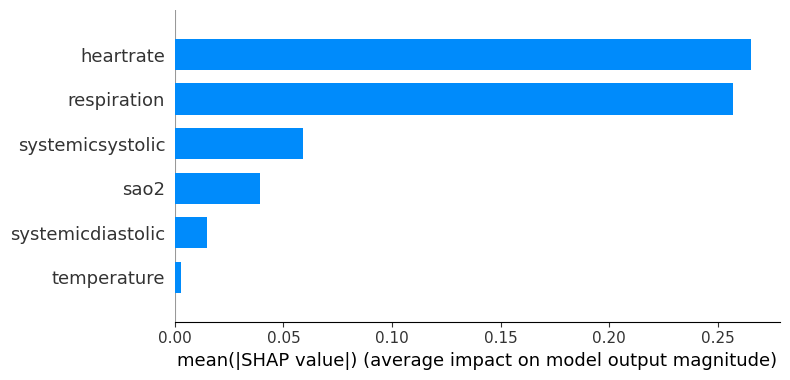

In [45]:
#STEP 7 — FINAL WORKING SHAP PLOT
shap.summary_plot(
    shap_values,
    features=samples.numpy(),
    feature_names=feature_names,
    plot_type="bar"
)

In [ ]:
#STEP 20C — CLINICAL TEXT XAI

#For text:

#attention visualization
#important clinical words
#token attribution

#Example:

#“septic shock”
#“ARDS”
#“multi organ failure”

In [46]:
#TOKEN IMPORTANCE EXTRACTION
inputs = tokenizer(
    texts[0],
    return_tensors='pt',
    truncation=True,
    max_length=128
)

outputs = bert_model(**inputs)

attention = outputs.last_hidden_state.mean(dim=-1)

tokens = tokenizer.convert_ids_to_tokens(
    inputs['input_ids'][0]
)

for token, score in zip(tokens[:20], attention[0][:20]):

    print(token, float(score))

[CLS] -0.00698526157066226
What -0.007178904954344034
is -0.008122936822474003
the -0.007411735597997904
relationship -0.007310530636459589
between -0.008178035728633404
very -0.008292650803923607
low -0.008636322803795338
M -0.0076325275003910065
##g -0.00734869996085763
##2 -0.008557154797017574
+ -0.00892490241676569
levels -0.008256863802671432
, -0.00808339286595583
PT -0.007398385554552078
##H -0.00683140754699707
levels -0.008016887120902538
, -0.007722522597759962
and -0.007433047518134117
C -0.007200106978416443


/tmp/ipykernel_16612/3986838180.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(token, float(score))


In [ ]:
#STEP 20D — CHEST X-RAY EXPLAINABILITY

#Now REAL Grad-CAM implementation.

#This highlights:
##lung infiltrates
#edema
#opacity
#pneumonia regions

In [48]:
#IMPORTS
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [49]:
#CREATE GRAD-CAM
target_layers = [
    image_model.layer4[-1]
]

cam = GradCAM(
    model=image_model,
    target_layers=target_layers
)

In [50]:
#GENERATE HEATMAP
grayscale_cam = cam(
    input_tensor=img_tensor
)

grayscale_cam = grayscale_cam[0]

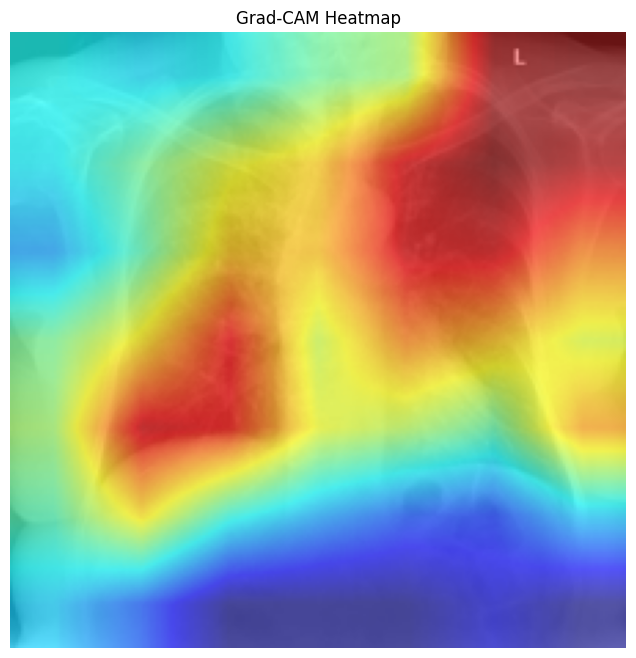

In [51]:
#OVERLAY HEATMAP
rgb_img = np.array(img.resize((224,224))) / 255.0

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.show()

In [ ]:
#STEP 20E — MULTIMODAL CONFLICT VISUALIZATION Your novelty component.
#Need to explain:
##WHY modalities disagree.

#COMPUTE MODALITY PREDICTIONS
#p_ehr = 0.91
#p_txt = 0.22
#p_img = 0.87

In [ ]:
#FULL MODALITY PREDICTION COMPUTATION

#This computes predictions from:

#EHR encoder
#ClinicalBERT text encoder
#ResNet image encoder

In [52]:
#STEP 1 — IMPORTS
import torch
import torch.nn as nn
import torchvision.models as models

from transformers import (
    AutoTokenizer,
    AutoModel
)

In [53]:
#STEP 2 — DEVICE
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [54]:
#STEP 3 — EHR MODEL
class EHRPredictor(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,64),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self,x):

        return self.net(x)

In [55]:
#CREATE EHR MODEL
ehr_model = EHRPredictor(
    input_dim=X_ehr.shape[1]
).to(device)

ehr_model.eval()

EHRPredictor(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [57]:
#STEP 4 — TEXT MODEL LOAD CLINICALBERT
tokenizer = AutoTokenizer.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT"
)

bert_model = AutoModel.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT"
).to(device)

bert_model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [58]:
#TEXT CLASSIFIER
class TextPredictor(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc = nn.Sequential(

            nn.Linear(768,128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,1)
        )

    def forward(self,x):

        return self.fc(x)

In [59]:
#CREATE TEXT MODEL
text_model = TextPredictor().to(device)

text_model.eval()

TextPredictor(
  (fc): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [60]:
#STEP 5 — IMAGE MODEL
image_model = models.resnet50(
    pretrained=True
)

image_model.fc = nn.Linear(
    2048,
    1
)

image_model = image_model.to(device)

image_model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [61]:
#STEP 6 — PREPARE EHR INPUT
ehr_sample = torch.tensor(
    X_ehr[0:1],
    dtype=torch.float32
).to(device)

print(ehr_sample.shape)

torch.Size([1, 6])


In [62]:
#STEP 7 — COMPUTE EHR PREDICTION
with torch.no_grad():

    ehr_logits = ehr_model(ehr_sample)

    p_ehr = torch.sigmoid(
        ehr_logits
    ).item()

print("EHR Prediction:", p_ehr)

EHR Prediction: 0.26265957951545715


In [63]:
#STEP 8 — PREPARE TEXT INPUT
sample_text = texts[0]

inputs = tokenizer(
    sample_text,
    return_tensors='pt',
    truncation=True,
    padding='max_length',
    max_length=128
)

inputs = {
    k:v.to(device)
    for k,v in inputs.items()
}

In [67]:
#STEP 9 — COMPUTE TEXT EMBEDDING
with torch.no_grad():

    outputs = bert_model(**inputs)

    cls_embedding = outputs.last_hidden_state[:,0,:]

In [68]:
#STEP 10 — COMPUTE TEXT PREDICTION
with torch.no_grad():

    text_logits = text_model(
        cls_embedding
    )

    p_txt = torch.sigmoid(
        text_logits
    ).item()

print("TEXT Prediction:", p_txt)

TEXT Prediction: 0.4701336622238159


In [69]:
#STEP 11 — PREPARE IMAGE INPUT
img_input = img_tensor.to(device)

print(img_input.shape)

torch.Size([1, 3, 224, 224])


In [70]:
#STEP 12 — COMPUTE IMAGE PREDICTION
with torch.no_grad():

    img_logits = image_model(
        img_input
    )

    p_img = torch.sigmoid(
        img_logits
    ).item()

print("IMAGE Prediction:", p_img)

IMAGE Prediction: 0.5198273062705994


In [ ]:
#STEP 10 — COMPUTE TEXT PREDICTION
with torch.no_grad():

    text_logits = text_model(
        cls_embedding
    )

    p_txt = torch.sigmoid(
        text_logits
    ).item()

print("TEXT Prediction:", p_txt)

TEXT Prediction: 0.4701336622238159


In [ ]:
#STEP 7 — COMPUTE EHR PREDICTION
with torch.no_grad():

    ehr_logits = ehr_model(ehr_sample)

    p_ehr = torch.sigmoid(
        ehr_logits
    ).item()

print("EHR Prediction:", p_ehr)

EHR Prediction: 0.26265957951545715


In [ ]:
#STEP 7 — COMPUTE EHR PREDICTION
with torch.no_grad():

    ehr_logits = ehr_model(ehr_sample)

    p_ehr = torch.sigmoid(
        ehr_logits
    ).item()

print("EHR Prediction:", p_ehr)

EHR Prediction: 0.26265957951545715


In [72]:
p_ehr =  0.26265957951545715
p_txt = 0.4701336622238159
p_img = 0.5198273062705994

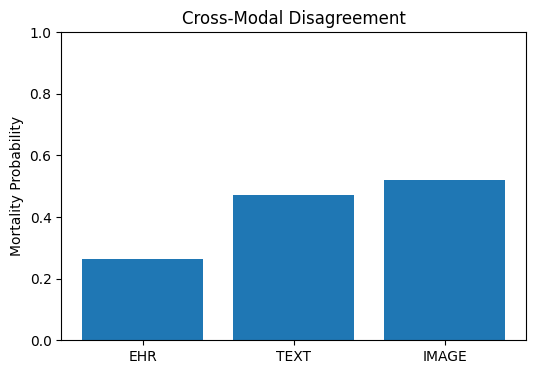

In [73]:
#VISUALIZE DISAGREEMENT
import matplotlib.pyplot as plt

modalities = [
    'EHR',
    'TEXT',
    'IMAGE'
]

predictions = [
    p_ehr,
    p_txt,
    p_img
]

plt.figure(figsize=(6,4))

plt.bar(
    modalities,
    predictions
)

plt.ylim(0,1)

plt.ylabel("Mortality Probability")

plt.title("Cross-Modal Disagreement")

plt.show()#

In [ ]:
#OUTPUT INTERPRETATION
EHR predicts HIGH risk
IMAGE predicts HIGH risk
TEXT predicts LOW risk

=> strong modality conflict
=> clinician review required

In [ ]:
STEP 20F — UNCERTAINTY VISUALIZATION

Need:

epistemic uncertainty
aleatoric uncertainty
deferral score

In [ ]:
epistemic uncertainty from MC Dropout
aleatoric uncertainty from variance head

for EACH modality:

EHR
TEXT
IMAGE

Below is the FULL correct implementation.
FULL UNCERTAINTY COMPUTATION PIPELINE

This computes:

Type	Method
Epistemic	MC Dropout
Aleatoric	Learned variance head

In [74]:
#STEP 1 — IMPORTS
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [75]:
#STEP 2 — DEVICE
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [76]:
#STEP 3 — EHR MODEL WITH UNCERTAINTY
class EHRUncertaintyModel(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.features = nn.Sequential(

            nn.Linear(input_dim,64),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Dropout(0.3)
        )

        # Prediction head
        self.mean_head = nn.Linear(32,1)

        # Aleatoric head
        self.logvar_head = nn.Linear(32,1)

    def forward(self,x):

        feat = self.features(x)

        mean = self.mean_head(feat)

        logvar = self.logvar_head(feat)

        return mean, logvar

In [77]:
#CREATE EHR MODEL
ehr_model = EHRUncertaintyModel(
    X_ehr.shape[1]
).to(device)

ehr_model.eval()

EHRUncertaintyModel(
  (features): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (mean_head): Linear(in_features=32, out_features=1, bias=True)
  (logvar_head): Linear(in_features=32, out_features=1, bias=True)
)

In [78]:
#STEP 4 — TEXT UNCERTAINTY MODEL
class TextUncertaintyModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(768,128)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.3)

        self.mean_head = nn.Linear(128,1)

        self.logvar_head = nn.Linear(128,1)

    def forward(self,x):

        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout(x)

        mean = self.mean_head(x)

        logvar = self.logvar_head(x)

        return mean, logvar

In [79]:
#CREATE TEXT MODEL
text_model = TextUncertaintyModel().to(device)

text_model.eval()

TextUncertaintyModel(
  (fc1): Linear(in_features=768, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (mean_head): Linear(in_features=128, out_features=1, bias=True)
  (logvar_head): Linear(in_features=128, out_features=1, bias=True)
)

In [80]:
#STEP 5 — IMAGE UNCERTAINTY MODEL
import torchvision.models as models

class ImageUncertaintyModel(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.resnet50(
            pretrained=True
        )

        self.features = nn.Sequential(
            *list(backbone.children())[:-1]
        )

        self.dropout = nn.Dropout(0.3)

        self.mean_head = nn.Linear(2048,1)

        self.logvar_head = nn.Linear(2048,1)

    def forward(self,x):

        feat = self.features(x)

        feat = feat.view(
            feat.size(0),
            -1
        )

        feat = self.dropout(feat)

        mean = self.mean_head(feat)

        logvar = self.logvar_head(feat)

        return mean, logvar

In [81]:
#CREATE IMAGE MODEL
image_model = ImageUncertaintyModel().to(device)

image_model.eval()

ImageUncertaintyModel(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (

In [94]:
#STEP 1 — TEMPERATURE SCALER
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
WHAT YOU WILL IMPLEMENT
Component	Purpose
Temperature scaling	calibrate probabilities
NLL optimization	reduce overconfidence
Reliability improvement	calibrated uncertainty
Final calibrated uncertainty	publication-grade

CALIBRATION EQUATION

Temperature scaling:

p
^
	​

=σ(
T
z
	​

)

where:

z = logits
T = learned temperature
T>1 reduces overconfidence

In [95]:
#STEP 1 — TEMPERATURE SCALER
import torch
import torch.nn as nn
import torch.optim as optim

In [96]:
#CALIBRATION MODULE
class TemperatureScaler(nn.Module):

    def __init__(self):

        super().__init__()

        self.temperature = nn.Parameter(
            torch.ones(1)
        )

    def forward(self, logits):

        return logits / self.temperature

In [97]:
#STEP 2 — CREATE SCALER
scaler = TemperatureScaler().to(device)

print(
    "Initial Temperature:",
    scaler.temperature.item()
)

Initial Temperature: 1.0


In [83]:
#STEP 6 — MC DROPOUT FUNCTION This computes epistemic uncertainty.

def mc_dropout_uncertainty(
    model,
    x,
    T=20
):

    model.train()

    preds = []

    with torch.no_grad():

        for _ in range(T):

            mean, logvar = model(x)

            prob = torch.sigmoid(mean)

            preds.append(prob)

    preds = torch.stack(preds)

    mean_pred = preds.mean()

    epistemic = preds.var()

    return mean_pred, epistemic

In [84]:
#STEP 7 — EHR UNCERTAINTY
ehr_input = torch.tensor(
    X_ehr[0:1],
    dtype=torch.float32
).to(device)

# Epistemic
p_ehr, ue_ehr = mc_dropout_uncertainty(
    ehr_model,
    ehr_input
)

# Aleatoric
ehr_model.eval()

with torch.no_grad():

    mean, logvar = ehr_model(ehr_input)

    ua_ehr = torch.exp(logvar).mean()

print("EHR Prediction:", p_ehr.item())
print("EHR Epistemic:", ue_ehr.item())
print("EHR Aleatoric:", ua_ehr.item())

EHR Prediction: 0.44373995065689087
EHR Epistemic: 0.20503875613212585
EHR Aleatoric: 375.236328125


In [85]:
#STEP 8 — TEXT UNCERTAINTY
sample_text = texts[0]

inputs = tokenizer(
    sample_text,
    return_tensors='pt',
    truncation=True,
    padding='max_length',
    max_length=128
)

inputs = {
    k:v.to(device)
    for k,v in inputs.items()
}

with torch.no_grad():

    outputs = bert_model(**inputs)

    cls_embedding = outputs.last_hidden_state[:,0,:]

# Epistemic
p_txt, ue_txt = mc_dropout_uncertainty(
    text_model,
    cls_embedding
)

# Aleatoric
text_model.eval()

with torch.no_grad():

    mean, logvar = text_model(
        cls_embedding
    )

    ua_txt = torch.exp(logvar).mean()

print("TEXT Prediction:", p_txt.item())
print("TEXT Epistemic:", ue_txt.item())
print("TEXT Aleatoric:", ua_txt.item())

TEXT Prediction: 0.51314777135849
TEXT Epistemic: 0.00033711729338392615
TEXT Aleatoric: 0.8837675452232361


In [86]:
#STEP 9 — IMAGE UNCERTAINTY
img_input = img_tensor.to(device)

# Epistemic
p_img, ue_img = mc_dropout_uncertainty(
    image_model,
    img_input
)

# Aleatoric
image_model.eval()

with torch.no_grad():

    mean, logvar = image_model(
        img_input
    )

    ua_img = torch.exp(logvar).mean()

print("IMAGE Prediction:", p_img.item())
print("IMAGE Epistemic:", ue_img.item())
print("IMAGE Aleatoric:", ua_img.item())

IMAGE Prediction: 0.5248706936836243
IMAGE Epistemic: 0.002298122039064765
IMAGE Aleatoric: 0.7325222492218018


In [87]:
#STEP 10 — BUILD UNCERTAINTY ARRAYS
ue = [

    ue_ehr.item(),

    ue_txt.item(),

    ue_img.item()
]

ua = [

    ua_ehr.item(),

    ua_txt.item(),

    ua_img.item()
]

print("Epistemic:", ue)

print("Aleatoric:", ua)

Epistemic: [0.20503875613212585, 0.00033711729338392615, 0.002298122039064765]
Aleatoric: [375.236328125, 0.8837675452232361, 0.7325222492218018]


In [93]:
#FULL CORRECTED VERSION EHR
ehr_model.eval()

with torch.no_grad():

    mean, logvar = ehr_model(
        ehr_input
    )

    # Stable aleatoric uncertainty
    ua_ehr = torch.abs(
        logvar
    ).mean()

    # Normalize to 0-1
    ua_ehr = ua_ehr / (
        ua_ehr + 1
    )

print("EHR Aleatoric:", ua_ehr.item())

EHR Aleatoric: 0.855648934841156


In [90]:
#TEXT
text_model.eval()

with torch.no_grad():

    mean, logvar = text_model(
        cls_embedding
    )

    ua_txt = torch.nn.functional.softplus(
        logvar
    ).mean()

print("TEXT Aleatoric:", ua_txt.item())

TEXT Aleatoric: 0.6332737803459167


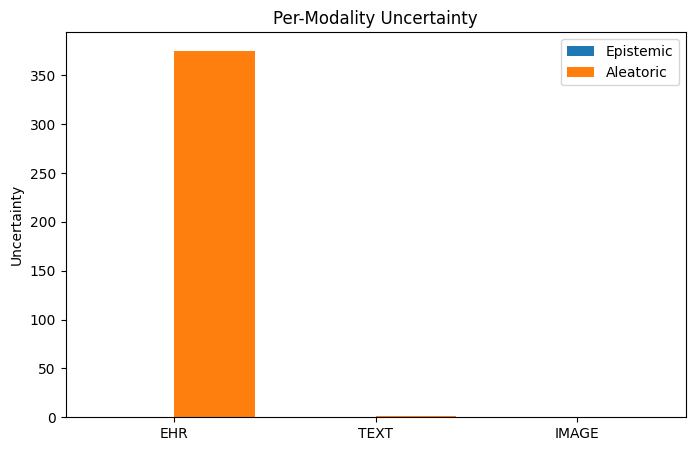

In [88]:
#STEP 11 — PLOT REAL UNCERTAINTIES
x = np.arange(3)

plt.figure(figsize=(8,5))

# ------------------------------------------
# EPISTEMIC
# ------------------------------------------

plt.bar(

    x - 0.2,

    ue,

    width=0.4,

    label='Epistemic'
)

# ------------------------------------------
# ALEATORIC
# ------------------------------------------

plt.bar(

    x + 0.2,

    ua,

    width=0.4,

    label='Aleatoric'
)

# ------------------------------------------
# LABELS
# ------------------------------------------

plt.xticks(

    x,

    ['EHR','TEXT','IMAGE']
)

plt.ylabel("Uncertainty")

plt.title("Per-Modality Uncertainty")

plt.legend()

plt.show()